<a href="https://colab.research.google.com/github/xavierjacomep/curso-intro-python/blob/main/11_PY_Manejo_de_Excepciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/9/99/Logo_UCSG.svg" width="300" alt="Logo">
</p>


# 🛡️ Módulo 11 — Manejo de Excepciones en Python

**Tiempo estimado:** 20 minutos

---

## 🎯 Objetivos

- Entender qué son las excepciones
- Usar `try-except` para manejar errores
- Capturar tipos específicos de excepciones
- Usar `else` y `finally`
- Aplicar manejo de errores en procesamiento de datos

---

## ¿Qué es una Excepción?

Una **excepción** es un error que ocurre durante la ejecución del programa. Si no la manejamos, el programa se detiene abruptamente.

En análisis de datos esto es crítico: imagina que tienes 10,000 registros y uno tiene datos corruptos. Sin manejo de excepciones, todo el proceso se detiene. Con manejo correcto, registras el error, saltas ese dato y continúas.

---
<hr>

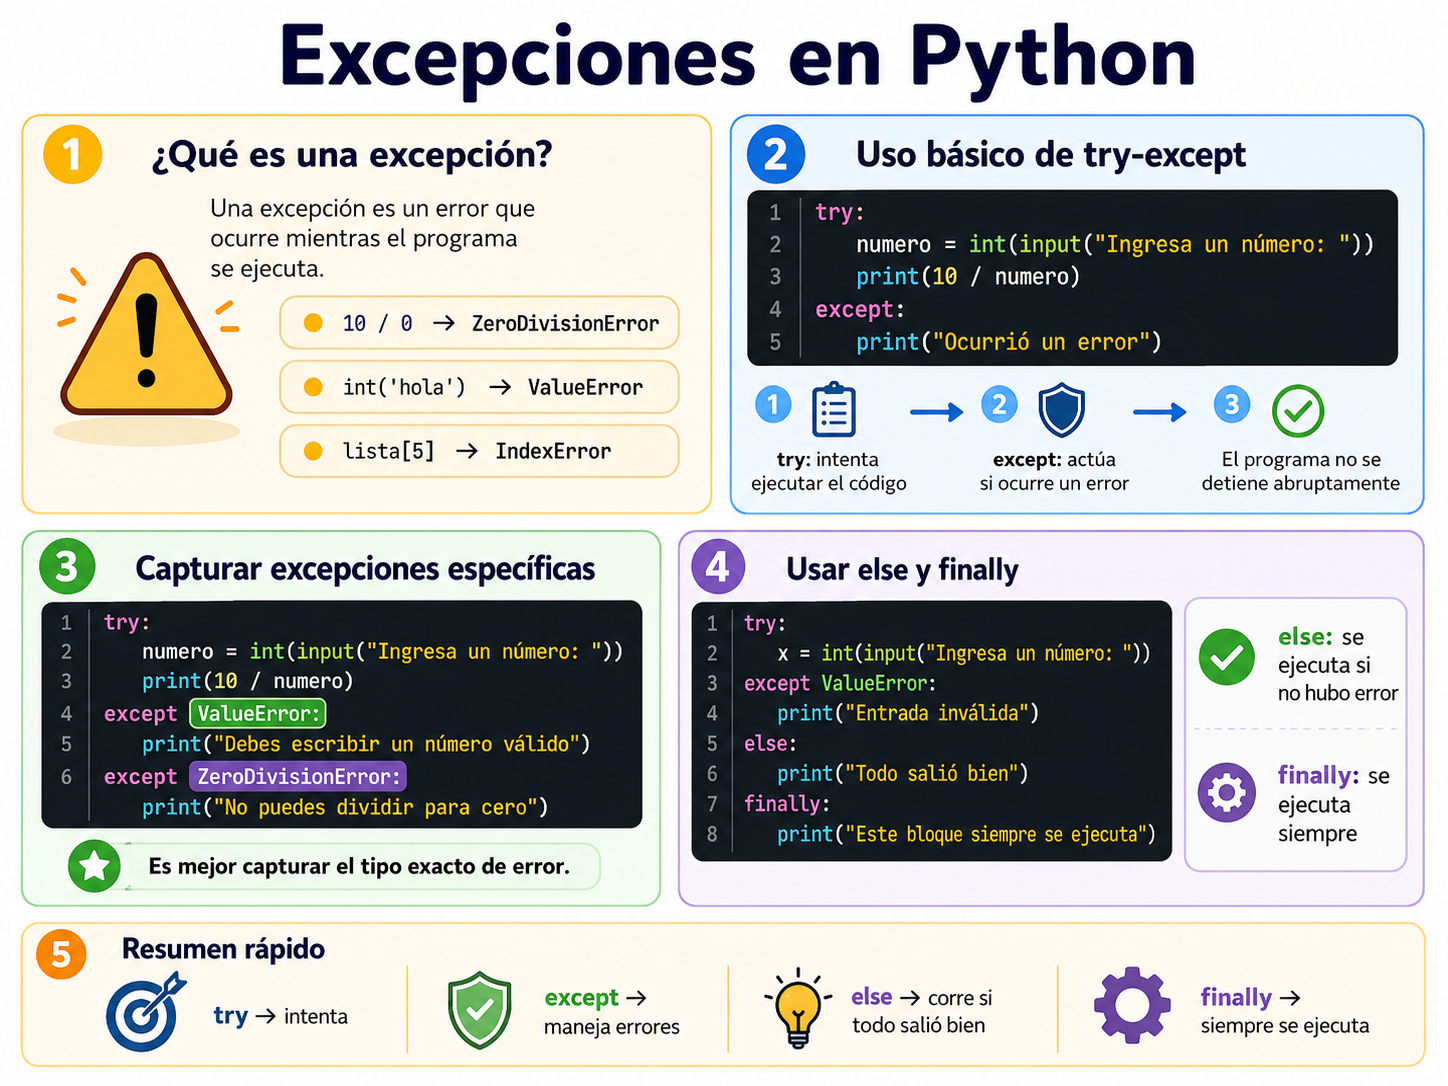

## Tipos de Excepciones más comunes

In [ ]:
# ZeroDivisionError: dividir por cero
# 1 / 0

In [ ]:
# NameError: variable no definida
# print(variable_inexistente)

In [ ]:
# IndexError: índice fuera de rango
# lista = [1, 2, 3]
# lista[10]

In [ ]:
# TypeError: operación con tipos incompatibles
# '100' + 50

In [ ]:
# ValueError: valor incorrecto para la operación
# int('abc')

## Estructura `try-except`

```python
try:
    # código que puede fallar
except TipoDeError:
    # qué hacer si falla
```

In [ ]:
# Sin manejo de excepciones — el programa se detiene
# ventas = 10000
# trabajadores = 0
# promedio = ventas / trabajadores  # ZeroDivisionError!

# CON manejo de excepciones — el programa continúa
ventas = 10000
trabajadores = 0

try:
    promedio = ventas / trabajadores
    print(f'Venta promedio por trabajador: ${promedio:,.2f}')
except ZeroDivisionError:
    print('Error: No hay trabajadores registrados. No se puede calcular el promedio.')

print('El programa continúa normalmente...')

In [ ]:
# Múltiples tipos de excepción
def convertir_a_numero(texto):
    """Convierte texto a número con manejo de errores."""
    try:
        numero = float(texto)
        resultado = 100 / numero
        return resultado
    except ValueError:
        print(f'Error: "{texto}" no es un número válido')
    except ZeroDivisionError:
        print('Error: No se puede dividir por cero')
    except Exception as e:
        print(f'Error inesperado: {e}')
    return None

# Pruebas
print(convertir_a_numero('25'))     # funciona bien
print(convertir_a_numero('abc'))    # ValueError
print(convertir_a_numero('0'))      # ZeroDivisionError

## `try-except-else-finally`

- **`else`**: se ejecuta si el `try` no generó error
- **`finally`**: se ejecuta siempre, con o sin error

In [ ]:
def procesar_pago(monto, saldo):
    """Procesa un pago con manejo completo de errores."""
    print(f'Procesando pago de ${monto:,}...')

    try:
        if not isinstance(monto, (int, float)):
            raise TypeError('El monto debe ser numérico')
        if monto <= 0:
            raise ValueError('El monto debe ser positivo')
        if monto > saldo:
            raise ValueError(f'Saldo insuficiente. Disponible: ${saldo:,}')

        nuevo_saldo = saldo - monto

    except TypeError as e:
        print(f'  ❌ Error de tipo: {e}')
        return None
    except ValueError as e:
        print(f'  ❌ Error de valor: {e}')
        return None
    else:
        # Solo se ejecuta si no hubo error
        print(f'  ✅ Pago exitoso. Nuevo saldo: ${nuevo_saldo:,}')
        return nuevo_saldo
    finally:
        # Siempre se ejecuta
        print('  Transacción finalizada.')

# Pruebas
procesar_pago(500, 2000)
print()
procesar_pago(3000, 2000)
print()
procesar_pago(-100, 2000)

## Aplicación en procesamiento de datos

In [ ]:
# Procesar una lista de datos con posibles errores
# (simula leer datos de un archivo con valores corruptos)

datos_crudos = ['1500', '2300', 'ERROR', '900', '', '4200', 'N/A', '1100']

datos_limpios = []
errores = []

for i, dato in enumerate(datos_crudos):
    try:
        valor = float(dato)
        datos_limpios.append(valor)
    except (ValueError, TypeError) as e:
        errores.append({'posicion': i, 'valor': dato, 'error': str(e)})

print(f'Datos válidos: {datos_limpios}')
print(f'Total válidos: {len(datos_limpios)}')
print(f'Total con error: {len(errores)}')
print(f'Suma de datos válidos: {sum(datos_limpios):,.0f}')
print()
print('Registro de errores:')
for err in errores:
    print(f"  Posición {err['posicion']}: '{err['valor']}' - {err['error']}")

## 🧪 Ejercicio

**Ejercicio:** Escribe una función `division_segura(a, b)` que:
- Divida `a / b`
- Si `b == 0`, retorne `None` e imprima un mensaje de error
- Si los valores no son numéricos, imprima un mensaje adecuado

In [ ]:
# Escribe tu función aquí


<details><summary>📌 Solución</summary>

```python
def division_segura(a, b):
    try:
        resultado = a / b
        return resultado
    except ZeroDivisionError:
        print('Error: no se puede dividir por cero')
        return None
    except TypeError:
        print('Error: los valores deben ser numéricos')
        return None

print(division_segura(10, 2))   # → 5.0
print(division_segura(10, 0))   # → None
print(division_segura('a', 2))  # → None
```
</details>

<hr>

## ✅ Resumen del Módulo 11

- Las **excepciones** son errores en tiempo de ejecución
- **`try-except`**: captura y maneja errores
- Tipos comunes: `ValueError`, `TypeError`, `ZeroDivisionError`, `IndexError`, `KeyError`
- **`else`**: código que se ejecuta solo si no hubo error
- **`finally`**: código que se ejecuta siempre (limpieza, cierre de archivos)
- **`raise`**: lanzar una excepción manualmente
- En análisis de datos: permite procesar datos imperfectos sin detener todo el proceso

Siguiente: **Lectura de archivos** — importar datos desde archivos de texto. 🚀